In [66]:
import pandas as pd
from scipy.optimize import brentq
import numpy as np
from datetime import date
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from scipy.optimize import curve_fit

# FASE 1 DATOS

In [67]:
al30 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\AL30 - Cotizaciones historicas.csv")
al30.head()

,especie,apertura,maximo,minimo,ultimo,fecha,volumen,cierre,timestamp,usd_apertura,usd_maximo,usd_minimo,usd_cierre
0,AL30-0002-C-CT-ARS,5981.0,6013.5,5981.0,5992.0,2021-08-24,331802,5992.0,1629774000,33.89,34.07,33.89,0
1,AL30-0002-C-CT-ARS,6007.5,6018.0,5990.0,5999.0,2021-08-25,446860,5999.0,1629860400,34.02,34.08,33.92,0
2,AL30-0002-C-CT-ARS,6008.0,6012.0,5995.0,6012.0,2021-08-26,561111,6012.0,1629946800,33.88,33.90,33.80,0
3,AL30-0002-C-CT-ARS,6035.0,6075.0,6030.0,6057.0,2021-08-27,653274,6057.0,1630033200,33.96,34.18,33.93,0
4,AL30-0002-C-CT-ARS,6080.0,6127.0,6080.0,6123.0,2021-08-30,504968,6123.0,1630292400,34.60,34.87,34.60,0


In [68]:
print(al30.describe())

            apertura        maximo         minimo         ultimo  \
count    1672.000000    1672.00000    1672.000000    1672.000000   
mean    30358.838669   43996.57598   42622.337895   45762.580102   
std     34202.375983   33615.74550   32805.150566   31421.310028   
min         0.000000       0.00000       0.000000    4837.500000   
25%         0.000000    6554.75000    6470.000000   10496.735000   
50%      9385.500000   49131.58500   46542.350000   48979.195000   
75%     65750.328750   73675.41600   71007.020750   73823.705000   
max    101900.000000  102980.00000  100360.000000  101450.000000   

            volumen         cierre     timestamp  usd_apertura   usd_maximo  \
count  1.672000e+03    1672.000000  1.672000e+03   1672.000000  1672.000000   
mean   9.215003e+07   45762.580102  1.710489e+09     28.898026    39.139139   
std    8.712251e+07   31421.310028  3.964031e+07     22.844119    21.651777   
min    0.000000e+00    4837.500000  1.629774e+09      0.000000     0.00

El precio que se usa es el de cierre, por tanto los 0 en el resto de casos no generan problemas

In [69]:
al30["timestamp"] = pd.to_datetime(al30["timestamp"], unit="s")
al30["timestamp"]

0      2021-08-24 03:00:00
1      2021-08-25 03:00:00
2      2021-08-26 03:00:00
3      2021-08-27 03:00:00
4      2021-08-30 03:00:00
               ...        
1667   2026-08-18 03:00:00
1668   2026-08-19 03:00:00
1669   2026-08-20 03:00:00
1670   2026-08-21 03:00:00
1671   2026-08-24 03:00:00
Name: timestamp, Length: 1672, dtype: datetime64[ns]

Realizamos el mismo procedimiento para el resto de instrumentos

In [70]:
#HARD DOLLAR
gd30 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\GD30 - Cotizaciones historicas.csv")
gd35 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\GD35 - Cotizaciones historicas.csv")
al35 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\AL35 - Cotizaciones historicas.csv")
al29 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\AL29 - Cotizaciones historicas.csv")
al41 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\AL41 - Cotizaciones historicas.csv")
ae38 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\AE38 - Cotizaciones historicas.csv")

#DOLLAR LINKED
tzv27 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TZV27 - Cotizaciones historicas.csv")
tzv28 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TZV28 - Cotizaciones historicas.csv")
tzvd8 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TZVD8 - Cotizaciones historicas.csv")
d15e7 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\D15E7 - Cotizaciones historicas.csv")
d31m7 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\D31M7 - Cotizaciones historicas.csv")

#CER
tx26 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TX26 - Cotizaciones historicas.csv")
tx28 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TX28 - Cotizaciones historicas.csv")
tzx27 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TZX27 - Cotizaciones historicas.csv")
tzx28 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TZX28 - Cotizaciones historicas.csv")

#TASA FIJA
s30s6 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\S30S6 - Cotizaciones historicas.csv")
s30n6 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\S30N6 - Cotizaciones historicas.csv")
to26 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\TO26 - Cotizaciones historicas.csv")
t31y7 = pd.read_csv("C:\\Program1\\Proyectos\\Curva de rendimientos y valuación de bonos soberanos argentinos\\T31Y7 - Cotizaciones historicas.csv")

In [71]:
print(gd30["cierre"].describe(),
    gd35["cierre"].describe(),
    al35["cierre"].describe(),
    al29["cierre"].describe(),
    al41["cierre"].describe(),
    ae38["cierre"].describe(),
    
    tx26["cierre"].describe(),
    tx28["cierre"].describe(),
    tzx27["cierre"].describe(),
    tzx28["cierre"].describe(),
    
    s30s6["cierre"].describe(),
    s30n6["cierre"].describe(),
    to26["cierre"].describe(),
    t31y7["cierre"].describe()
)

count      1676.000000
mean      47888.423335
std       31697.536273
min        5464.000000
25%       12959.750000
50%       51718.670000
75%       76173.785000
max      105610.000000
Name: cierre, dtype: float64 count      1185.000000
mean      48230.291181
std       40605.378732
min        5300.000000
25%        7700.000000
50%       39372.780000
75%       79718.720000
max      130700.000000
Name: cierre, dtype: float64 count      1184.000000
mean      47101.119696
std       39805.634151
min        5050.000000
25%        7308.500000
50%       38473.790000
75%       78880.650000
max      125290.000000
Name: cierre, dtype: float64 count      1177.000000
mean      45377.245650
std       34473.057487
min        5050.720000
25%        7749.000000
50%       42980.660000
75%       77235.280000
max      106630.000000
Name: cierre, dtype: float64 count      1181.000000
mean      45093.272735
std       36846.308140
min        6075.000000
25%        8899.000000
50%       37953.760000
75%       

In [72]:
gd30["timestamp"] = pd.to_datetime(gd30["timestamp"], unit="s")
gd35["timestamp"] = pd.to_datetime(gd35["timestamp"], unit="s")
al35["timestamp"] = pd.to_datetime(al35["timestamp"], unit="s")
al29["timestamp"] = pd.to_datetime(al29["timestamp"], unit="s")
al41["timestamp"] = pd.to_datetime(al41["timestamp"], unit="s")
ae38["timestamp"] = pd.to_datetime(ae38["timestamp"], unit="s")
tx26["timestamp"] = pd.to_datetime(tx26["timestamp"], unit="s")
tx28["timestamp"] = pd.to_datetime(tx28["timestamp"], unit="s")
tzx27["timestamp"] = pd.to_datetime(tzx27["timestamp"], unit="s")
tzx28["timestamp"] = pd.to_datetime(tzx28["timestamp"], unit="s")
s30s6["timestamp"] = pd.to_datetime(s30s6["timestamp"], unit="s")
s30n6["timestamp"] = pd.to_datetime(s30n6["timestamp"], unit="s")
to26["timestamp"] = pd.to_datetime(to26["timestamp"], unit="s")
t31y7["timestamp"] = pd.to_datetime(t31y7["timestamp"], unit="s")

In [73]:
# Valores Dolar (al dia de la realizacion del proyecto)
mep        = 1544.10 
tc_oficial =  1535

bonos_data = {
    "ticker": [
        # Hard dollar
        "AL30", "GD30",  "GD35",  "AL35",  "AL29",  "AL41",  "AE38",
        # Dollar-linked
        "TZV27", "TZV28", "TZVD8", "D15E7", "D31M7",
        # CER
        "TX26",  "TX28",  "TZX27", "TZX28",
        # Tasa fija
        "S30S6", "S30N6", "TO26",  "T31Y7",
    ],
    "tipo": [
        "hard_dollar", "hard_dollar",   "hard_dollar",   "hard_dollar",    "hard_dollar",   "hard_dollar",   "hard_dollar",
        "dollar_linked", "dollar_linked", "dollar_linked", "dollar_linked", "dollar_linked",
        "CER",  "CER",  "CER",  "CER",
        "tasa_fija", "tasa_fija", "tasa_fija", "tasa_fija",
    ],
    "precio_cierre": [# Hard dollar
        al30["cierre"].iloc[-1],
        gd30["cierre"].iloc[-1],
        gd35["cierre"].iloc[-1],
        al35["cierre"].iloc[-1],
        al29["cierre"].iloc[-1],
        al41["cierre"].iloc[-1],
        ae38["cierre"].iloc[-1],
        # Dollar-linked
        tzv27["cierre"].iloc[-1],
        tzv28["cierre"].iloc[-1],
        tzvd8["cierre"].iloc[-1],
        d15e7["cierre"].iloc[-1],
        d31m7["cierre"].iloc[-1],
        # CER
        tx26["cierre"].iloc[-1],
        tx28["cierre"].iloc[-1],
        tzx27["cierre"].iloc[-1],
        tzx28["cierre"].iloc[-1],
        # Tasa fija
        s30s6["cierre"].iloc[-1],
        s30n6["cierre"].iloc[-1],
        to26["cierre"].iloc[-1],
        t31y7["cierre"].iloc[-1],
    ],
    "vencimiento": [
        "2030-07-09",  # AL30
        "2030-07-09",  # GD30
        "2035-07-09",  # GD35
        "2035-07-09",  # AL35
        "2029-07-09",  # AL29
        "2041-07-09",  # AL41 
        "2038-01-09",  # AE38

        "2027-06-30",  # TZV27
        "2028-06-30",  # TZV28
        "2028-12-15",  # TZVD8
        "2027-01-15",  # D15E7
        "2027-03-31",  # D31M7

        "2026-11-09",  # TX26
        "2028-11-09",  # TX28
        "2027-06-30",  # TZX27 
        "2028-06-30",  # TZX28 

        "2026-09-30",  # S30S6
        "2026-11-30",  # S30N6
        "2026-10-17",  # TO26
        "2027-05-31",  # T31Y7
    ],
    "cupon": [
        0.0075,   # AL30  — step-up vigente 0.75% (jul-2023 a jul-2027)
        0.0075,   # GD30  — idem AL30
        0.04125,  # GD35  — step-up vigente 4.125%
        0.04125,  # AL35  — ídem GD35
        0.0100,   # AL29 
        0.0350,   # AL41 
        0.0500,   # AE38 

        0.0000,   # TZV27 — cero cupón dollar-linked
        0.0000,   # TZV28 — cero cupón dollar-linked
        0.0000,   # TZVD8 — cero cupón dollar-linked
        0.0000,   # D15E7 — cero cupón LELINK
        0.0000,   # D31M7 — cero cupón LELINK

        0.0200,   # TX26  — CER + 2%
        0.0225,   # TX28  — CER + 2.25%
        0.0000,   # TZX27 — LECER, cero cupón
        0.0000,   # TZX28 — LECER, cero cupón

        0.0000,   # S30S6 — LECAP
        0.0000,   # S30N6 — LECAP
        0.1550,   # TO26  — 15.5% fijo anual (emitido 2016)
        0.0000,   # T31Y7 — BONCAP
    ],
    "frecuencia": [
        2,  # AL30
        2,  # GD30
        2,  # GD35
        2,  # AL35
        2,  # AL29
        2,  # AL41
        2,  # AE38

        0,  # TZV27
        0,  # TZV28
        0,  # TZVD8
        0,  # D15E7
        0,  # D31M7

        2,  # TX26
        2,  # TX28
        0,  # TZX27
        0,  # TZX28

        0,  # S30S6
        0,  # S30N6
        2,  # TO26
        0,  # T31Y7
    ],
    "amortizacion": [
        "escalonada",  # AL30
        "escalonada",  # GD30
        "escalonada",  # GD35
        "escalonada",  # AL35
        "escalonada",  # AL29
        "escalonada",  # AL41
        "escalonada",  # AE38

        "bullet",      # TZV27
        "bullet",      # TZV28
        "bullet",      # TZVD8
        "bullet",      # D15E7
        "bullet",      # D31M7

        "escalonada",  # TX26
        "escalonada",  # TX28
        "bullet",      # TZX27
        "bullet",      # TZX28

        "bullet",      # S30S6
        "bullet",      # S30N6
        "bullet",      # TO26
        "bullet",      # T31Y7
    ],
}

bonos = pd.DataFrame(bonos_data)
bonos["vencimiento"] = pd.to_datetime(bonos["vencimiento"])

bonos["tipo_cambio"] = bonos["tipo"].map({
    "hard_dollar":   mep,
    "dollar_linked": tc_oficial,  # TC oficial, no MEP
    "CER":           1,
    "tasa_fija":     1,
})

In [74]:
hoy = pd.Timestamp(date.today())
bonos["plazo_anos"] = (bonos["vencimiento"] - hoy).dt.days / 365

In [75]:
bonos

,ticker,tipo,precio_cierre,vencimiento,cupon,frecuencia,amortizacion,tipo_cambio,plazo_anos
0,AL30,hard_dollar,84860.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096
1,GD30,hard_dollar,88050.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096
2,GD35,hard_dollar,122710.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836
3,AL35,hard_dollar,115560.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836
4,AL29,hard_dollar,82580.00,2029-07-09,0.01000,2,escalonada,1544.1,2.841096
5,AL41,hard_dollar,108800.00,2041-07-09,0.03500,2,escalonada,1544.1,14.849315
6,AE38,hard_dollar,120750.00,2038-01-09,0.05000,2,escalonada,1544.1,11.350685
7,TZV27,dollar_linked,147800.00,2027-06-30,0.00000,0,bullet,1535.0,0.813699
8,TZV28,dollar_linked,125880.00,2028-06-30,0.00000,0,bullet,1535.0,1.816438
9,TZVD8,dollar_linked,119450.00,2028-12-15,0.00000,0,bullet,1535.0,2.276712


Se deberá respetar el escalonamiento luego (aqui el cupon es de referencia)

In [76]:
# Último pago de cupón 
# None para frecuencia=0
ultimo_pago = {
    # Hard dollar
    "AL30":  pd.Timestamp("2026-07-09"),
    "GD30":  pd.Timestamp("2026-07-09"),
    "GD35":  pd.Timestamp("2026-07-09"),
    "AL35":  pd.Timestamp("2026-07-09"),
    "AL29":  pd.Timestamp("2026-07-09"),
    "AL41":  pd.Timestamp("2026-07-09"),
    "AE38":  pd.Timestamp("2026-07-09"),
    # Dollar-linked 
    "TZV27": None,
    "TZV28": None,
    "TZVD8": None,
    "D15E7": None,
    "D31M7": None,
    # CER con cupón
    "TX26":  pd.Timestamp("2026-05-09"),
    "TX28":  pd.Timestamp("2026-05-09"),
    # CER sin cupón
    "TZX27": None,
    "TZX28": None,
    # Tasa fija sin cupón (capitalizan)
    "S30S6": None,
    "S30N6": None,
    "T31Y7": None,
    # Tasa fija con cupón semestral
    "TO26":  pd.Timestamp("2026-04-17"),  # semestral desde oct-2016
}

# ── Valor técnico ──────────────────────────────────────────────────────────
# Hard dollar : fracción residual del VN original en USD
# CER con cupón: VT ajustado por CER
# frecuencia=0: 0.0 — irrelevante para el corrido
bonos["valor_tecnico"] = [
    0.6406,   # AL30
    0.6406,   # GD30
    1.0053,   # GD35 
    1.0053,   # AL35 
    0.6009,   # AL29
    1.0048,   # AL41
    1.0072,   # AE38  
    0.0,      # TZV27
    0.0,      # TZV28
    0.0,      # TZVD8
    0.0,      # D15E7
    0.0,      # D31M7
    733.08,   # TX26 
    1834.07,  # TX28  
    410.15,   # TZX27
    413.97,   # TZX28
    1.169,    # S30S6 
    1.2166,   # S30N6
    105.51,   # TO26  
    1.2479,   # T31Y7
]

# ── Cupón corrido ──────────────────────────────────────────────────────────
def cupon_corrido(row):
    if row["frecuencia"] == 0:
        return 0.0
    upago = ultimo_pago.get(row["ticker"])
    vt    = row["valor_tecnico"]
    if upago is None or vt is None:
        return None   # dato faltante
    dias = (hoy - upago).days
    return row["cupon"] * (dias / 360) * vt * row["tipo_cambio"]

bonos["cupon_corrido"] = bonos.apply(cupon_corrido, axis=1)
bonos["precio_sucio"]  = bonos["precio_cierre"]
bonos["precio_limpio"] = bonos["precio_sucio"] - bonos["cupon_corrido"]


In [77]:
bonos

,ticker,tipo,precio_cierre,vencimiento,cupon,frecuencia,amortizacion,tipo_cambio,plazo_anos,valor_tecnico,cupon_corrido,precio_sucio,precio_limpio
0,AL30,hard_dollar,84860.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096,0.6406,1.215831,84860.00,84858.784169
1,GD30,hard_dollar,88050.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096,0.6406,1.215831,88050.00,88048.784169
2,GD35,hard_dollar,122710.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836,1.0053,10.494085,122710.00,122699.505915
3,AL35,hard_dollar,115560.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836,1.0053,10.494085,115560.00,115549.505915
4,AL29,hard_dollar,82580.00,2029-07-09,0.01000,2,escalonada,1544.1,2.841096,0.6009,1.520643,82580.00,82578.479357
5,AL41,hard_dollar,108800.00,2041-07-09,0.03500,2,escalonada,1544.1,14.849315,1.0048,8.899643,108800.00,108791.100357
6,AE38,hard_dollar,120750.00,2038-01-09,0.05000,2,escalonada,1544.1,11.350685,1.0072,12.744144,120750.00,120737.255856
7,TZV27,dollar_linked,147800.00,2027-06-30,0.00000,0,bullet,1535.0,0.813699,0.0000,0.000000,147800.00,147800.000000
8,TZV28,dollar_linked,125880.00,2028-06-30,0.00000,0,bullet,1535.0,1.816438,0.0000,0.000000,125880.00,125880.000000
9,TZVD8,dollar_linked,119450.00,2028-12-15,0.00000,0,bullet,1535.0,2.276712,0.0000,0.000000,119450.00,119450.000000


# FASE 2 TIR

In [78]:
amort_schedules = {

    # HARD DOLLAR
    # AL30: 8 pagos de 8%
    "AL30": {
        pd.Timestamp("2027-01-09"): 0.08,
        pd.Timestamp("2027-07-09"): 0.08,
        pd.Timestamp("2028-01-09"): 0.08,
        pd.Timestamp("2028-07-09"): 0.08,
        pd.Timestamp("2029-01-09"): 0.08,
        pd.Timestamp("2029-07-09"): 0.08,
        pd.Timestamp("2030-01-09"): 0.08,
        pd.Timestamp("2030-07-09"): 0.08,
    },

    "GD30": {
        pd.Timestamp("2027-01-09"): 0.08,
        pd.Timestamp("2027-07-09"): 0.08,
        pd.Timestamp("2028-01-09"): 0.08,
        pd.Timestamp("2028-07-09"): 0.08,
        pd.Timestamp("2029-01-09"): 0.08,
        pd.Timestamp("2029-07-09"): 0.08,
        pd.Timestamp("2030-01-09"): 0.08,
        pd.Timestamp("2030-07-09"): 0.08,
    },

    # AL29: 10 cuotas de 10%
    # 4 pagos realizados (ene/jul 2025, ene/jul 2026), residual 60% 
    "AL29": {
        pd.Timestamp("2027-01-09"): 0.10,
        pd.Timestamp("2027-07-09"): 0.10,
        pd.Timestamp("2028-01-09"): 0.10,
        pd.Timestamp("2028-07-09"): 0.10,
        pd.Timestamp("2029-01-09"): 0.10,
        pd.Timestamp("2029-07-09"): 0.10,
    },

    # GD35 / AL35: 10 cuotas de 10% desde ene-2031
    "GD35": {
        pd.Timestamp("2031-01-09"): 0.10,
        pd.Timestamp("2031-07-09"): 0.10,
        pd.Timestamp("2032-01-09"): 0.10,
        pd.Timestamp("2032-07-09"): 0.10,
        pd.Timestamp("2033-01-09"): 0.10,
        pd.Timestamp("2033-07-09"): 0.10,
        pd.Timestamp("2034-01-09"): 0.10,
        pd.Timestamp("2034-07-09"): 0.10,
        pd.Timestamp("2035-01-09"): 0.10,
        pd.Timestamp("2035-07-09"): 0.10,
    },
    "AL35": {
        pd.Timestamp("2031-01-09"): 0.10,
        pd.Timestamp("2031-07-09"): 0.10,
        pd.Timestamp("2032-01-09"): 0.10,
        pd.Timestamp("2032-07-09"): 0.10,
        pd.Timestamp("2033-01-09"): 0.10,
        pd.Timestamp("2033-07-09"): 0.10,
        pd.Timestamp("2034-01-09"): 0.10,
        pd.Timestamp("2034-07-09"): 0.10,
        pd.Timestamp("2035-01-09"): 0.10,
        pd.Timestamp("2035-07-09"): 0.10,
    },

    "AE38": {
        pd.Timestamp("2027-07-09"): 1/22,
        pd.Timestamp("2028-01-09"): 1/22,
        pd.Timestamp("2028-07-09"): 1/22,
        pd.Timestamp("2029-01-09"): 1/22,
        pd.Timestamp("2029-07-09"): 1/22,
        pd.Timestamp("2030-01-09"): 1/22,
        pd.Timestamp("2030-07-09"): 1/22,
        pd.Timestamp("2031-01-09"): 1/22,
        pd.Timestamp("2031-07-09"): 1/22,
        pd.Timestamp("2032-01-09"): 1/22,
        pd.Timestamp("2032-07-09"): 1/22,
        pd.Timestamp("2033-01-09"): 1/22,
        pd.Timestamp("2033-07-09"): 1/22,
        pd.Timestamp("2034-01-09"): 1/22,
        pd.Timestamp("2034-07-09"): 1/22,
        pd.Timestamp("2035-01-09"): 1/22,
        pd.Timestamp("2035-07-09"): 1/22,
        pd.Timestamp("2036-01-09"): 1/22,
        pd.Timestamp("2036-07-09"): 1/22,
        pd.Timestamp("2037-01-09"): 1/22,
        pd.Timestamp("2037-07-09"): 1/22,
        pd.Timestamp("2038-01-09"): 1/22,
    },

    "AL41": {
        pd.Timestamp("2028-01-09"): 1/28,
        pd.Timestamp("2028-07-09"): 1/28,
        pd.Timestamp("2029-01-09"): 1/28,
        pd.Timestamp("2029-07-09"): 1/28,
        pd.Timestamp("2030-01-09"): 1/28,
        pd.Timestamp("2030-07-09"): 1/28,
        pd.Timestamp("2031-01-09"): 1/28,
        pd.Timestamp("2031-07-09"): 1/28,
        pd.Timestamp("2032-01-09"): 1/28,
        pd.Timestamp("2032-07-09"): 1/28,
        pd.Timestamp("2033-01-09"): 1/28,
        pd.Timestamp("2033-07-09"): 1/28,
        pd.Timestamp("2034-01-09"): 1/28,
        pd.Timestamp("2034-07-09"): 1/28,                        
        pd.Timestamp("2035-01-09"): 1/28,
        pd.Timestamp("2035-07-09"): 1/28,
        pd.Timestamp("2036-01-09"): 1/28,
        pd.Timestamp("2036-07-09"): 1/28,
        pd.Timestamp("2037-01-09"): 1/28,
        pd.Timestamp("2037-07-09"): 1/28,
        pd.Timestamp("2038-01-09"): 1/28,
        pd.Timestamp("2038-07-09"): 1/28,
        pd.Timestamp("2039-01-09"): 1/28,
        pd.Timestamp("2039-07-09"): 1/28,
        pd.Timestamp("2040-01-09"): 1/28,
        pd.Timestamp("2040-07-09"): 1/28,
        pd.Timestamp("2041-01-09"): 1/28,
        pd.Timestamp("2041-07-09"): 1/28, 
    },

    # DOLLAR LINKED bullet, frecuencia=0
    "TZV27": {},
    "TZV28": {},
    "TZVD8": {},
    "D15E7": {},
    "D31M7": {},

    # CER
    "TX26": {
        pd.Timestamp("2026-11-09"): 733.08,
    },

    "TX28": {
        pd.Timestamp("2026-11-09"): 366.81,
        pd.Timestamp("2027-05-09"): 366.81,
        pd.Timestamp("2027-11-09"): 366.81,
        pd.Timestamp("2028-05-09"): 366.81,
        pd.Timestamp("2028-11-09"): 366.81,
    },

    "TZX27": {},
    "TZX28": {},

    # TASA FIJA
    # TO26: bullet, única amortización al vencimiento
    "TO26": {
        pd.Timestamp("2026-10-17"): 100.0,
    },

    # S30S6, S30N6, T31Y7: capitalizan, frecuencia=0
    "S30S6": {},
    "S30N6": {},
    "T31Y7": {},
}

In [79]:
cupon_schedules = {
    "AL30": {
        pd.Timestamp("2027-01-09"): 0.0075,
        pd.Timestamp("2027-07-09"): 0.0075,  
        pd.Timestamp("2028-01-09"): 0.0175,  
        pd.Timestamp("2028-07-09"): 0.0175,
        pd.Timestamp("2029-01-09"): 0.0175,
        pd.Timestamp("2029-07-09"): 0.0175,
        pd.Timestamp("2030-01-09"): 0.0175,
        pd.Timestamp("2030-07-09"): 0.0175,
    },
    "AL35": {
        pd.Timestamp("2027-01-09"): 0.04125,
        pd.Timestamp("2027-07-09"): 0.04125,  
        pd.Timestamp("2028-01-09"): 0.0475,  
        pd.Timestamp("2028-07-09"): 0.0475,   
        pd.Timestamp("2029-01-09"): 0.0500,   
        pd.Timestamp("2029-07-09"): 0.0500,
        pd.Timestamp("2030-01-09"): 0.0500,
        pd.Timestamp("2030-07-09"): 0.0500,
        pd.Timestamp("2031-01-09"): 0.0500,
        pd.Timestamp("2031-07-09"): 0.0500,
        pd.Timestamp("2032-01-09"): 0.0500,
        pd.Timestamp("2032-07-09"): 0.0500,
        pd.Timestamp("2033-01-09"): 0.0500,
        pd.Timestamp("2033-07-09"): 0.0500,
        pd.Timestamp("2034-01-09"): 0.0500,
        pd.Timestamp("2034-07-09"): 0.0500,
        pd.Timestamp("2035-01-09"): 0.0500,
        pd.Timestamp("2035-07-09"): 0.0500,
    },
    "AL41": {
        pd.Timestamp("2027-01-09"): 0.0350,
        pd.Timestamp("2027-07-09"): 0.0350,
        pd.Timestamp("2028-01-09"): 0.0350,
        pd.Timestamp("2028-07-09"): 0.0350,
        pd.Timestamp("2029-01-09"): 0.0350,
        pd.Timestamp("2029-07-09"): 0.0350,
        pd.Timestamp("2030-01-09"): 0.04875,
        pd.Timestamp("2030-07-09"): 0.04875,
        pd.Timestamp("2031-01-09"): 0.04875,
        pd.Timestamp("2031-07-09"): 0.04875,
        pd.Timestamp("2032-01-09"): 0.04875,
        pd.Timestamp("2032-07-09"): 0.04875,
        pd.Timestamp("2033-01-09"): 0.04875,
        pd.Timestamp("2033-07-09"): 0.04875,
        pd.Timestamp("2034-01-09"): 0.04875,
        pd.Timestamp("2034-07-09"): 0.04875,
        pd.Timestamp("2035-01-09"): 0.04875,
        pd.Timestamp("2035-07-09"): 0.04875,
        pd.Timestamp("2036-01-09"): 0.04875,
        pd.Timestamp("2036-07-09"): 0.04875,
        pd.Timestamp("2037-01-09"): 0.04875,
        pd.Timestamp("2037-07-09"): 0.04875,
        pd.Timestamp("2038-01-09"): 0.04875,
        pd.Timestamp("2038-07-09"): 0.04875,
        pd.Timestamp("2039-01-09"): 0.04875,
        pd.Timestamp("2039-07-09"): 0.04875,
        pd.Timestamp("2040-01-09"): 0.04875,
        pd.Timestamp("2040-07-09"): 0.04875,
        pd.Timestamp("2041-01-09"): 0.04875,
        pd.Timestamp("2041-07-09"): 0.04875,
    },
}

In [80]:

bonos["vt_vencimiento"] = [
    np.nan,   # AL30
    np.nan,   # GD30
    np.nan,   # GD35
    np.nan,   # AL35
    np.nan,   # AL29
    np.nan,   # AL41
    np.nan,   # AE38
    100*tc_oficial,   # TZV27
    100*tc_oficial,   # TZV28
    100*tc_oficial,   # TZVD8
    100*tc_oficial,   # D15E7
    100*tc_oficial,   # D31M7
    np.nan,   # TX26
    np.nan,   # TX28
    410,      # TZX27 + CER
    410,   # TZX28 + CER
    116.90,   # S30S6
    129.89,   # S30N6
    np.nan,   # TO26
    151.57,   # T31Y7
]

def generar_flujos(ticker, hoy, ultimo_pago_dict, amort_schedules,
                   vt_inicial, cupon, frecuencia, vencimiento,
                   cupon_schedules):
    flujos   = []
    residual = vt_inicial
    schedule = amort_schedules.get(ticker, {})
    cup_sch  = (cupon_schedules or {}).get(ticker, {})
    periodo  = pd.DateOffset(months=12 // frecuencia)
    fecha    = ultimo_pago_dict[ticker]
    

    while fecha <= vencimiento:
        fecha += periodo
        if fecha <= hoy:
            residual -= schedule.get(fecha, 0.0)
            continue

        amort = schedule.get(fecha, 0.0)

        # Si existe step-up para esta fecha, lo usa; sino usa el cupón base
        tasa_cupon = cup_sch.get(fecha, cupon)
        cupon_pago = (tasa_cupon / frecuencia) * residual

        flujos.append(((fecha - hoy).days / 365, cupon_pago + amort))
        residual -= amort

    return flujos

# calcular_ytm 
def calcular_ytm(precio, flujos):
    def f(r):
        return sum(cf / (1 + r)**t for t, cf in flujos) - precio
    try:
        return brentq(f, -0.999, 10.0)
    except ValueError:
        return np.nan

# loop principal 
ytm_results = []

for _, row in bonos.iterrows():
    ticker = row["ticker"]
    precio = row["precio_sucio"]

    # LECAP: cero cupón, fórmula directa
    if row["frecuencia"] == 0:
        vt_vto = row["vt_vencimiento"]
        if pd.isna(vt_vto) or row["plazo_anos"] <= 0:
            ytm_results.append(np.nan)
        else:
            ytm_results.append((vt_vto / precio) ** (1 / row["plazo_anos"]) - 1)
        continue

    flujos = generar_flujos(
        ticker           = ticker,
        hoy              = hoy,
        ultimo_pago_dict = ultimo_pago,
        amort_schedules  = amort_schedules,
        vt_inicial       = row["valor_tecnico"],
        cupon            = row["cupon"],
        frecuencia       = int(row["frecuencia"]),
        vencimiento      = row["vencimiento"],
        cupon_schedules  = cupon_schedules,
    )

    if not flujos:
        ytm_results.append(np.nan)
        continue

    # Hard dollar:
    if row["tipo"] == "hard_dollar":
        precio_usd = precio / mep
        flujos_usd = [(t, cf * 100) for t, cf in flujos]
        ytm_results.append(calcular_ytm(precio_usd, flujos_usd))

    # CER:
    elif row["tipo"] in ("CER", "tasa_fija"):
        ytm_results.append(calcular_ytm(precio, flujos))
    else:
        ytm_results.append(np.nan)

bonos["ytm"] = ytm_results

In [81]:
bonos

,ticker,tipo,precio_cierre,vencimiento,cupon,frecuencia,amortizacion,tipo_cambio,plazo_anos,valor_tecnico,cupon_corrido,precio_sucio,precio_limpio,vt_vencimiento,ytm
0,AL30,hard_dollar,84860.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096,0.6406,1.215831,84860.00,84858.784169,NaN,0.093999
1,GD30,hard_dollar,88050.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096,0.6406,1.215831,88050.00,88048.784169,NaN,0.066945
2,GD35,hard_dollar,122710.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836,1.0053,10.494085,122710.00,122699.505915,NaN,0.086252
3,AL35,hard_dollar,115560.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836,1.0053,10.494085,115560.00,115549.505915,NaN,0.106728
4,AL29,hard_dollar,82580.00,2029-07-09,0.01000,2,escalonada,1544.1,2.841096,0.6009,1.520643,82580.00,82578.479357,NaN,0.088975
5,AL41,hard_dollar,108800.00,2041-07-09,0.03500,2,escalonada,1544.1,14.849315,1.0048,8.899643,108800.00,108791.100357,NaN,0.104833
6,AE38,hard_dollar,120750.00,2038-01-09,0.05000,2,escalonada,1544.1,11.350685,1.0072,12.744144,120750.00,120737.255856,NaN,0.107790
7,TZV27,dollar_linked,147800.00,2027-06-30,0.00000,0,bullet,1535.0,0.813699,0.0000,0.000000,147800.00,147800.000000,153500.00,0.047603
8,TZV28,dollar_linked,125880.00,2028-06-30,0.00000,0,bullet,1535.0,1.816438,0.0000,0.000000,125880.00,125880.000000,153500.00,0.115395
9,TZVD8,dollar_linked,119450.00,2028-12-15,0.00000,0,bullet,1535.0,2.276712,0.0000,0.000000,119450.00,119450.000000,153500.00,0.116457


El plazo de años de AL30/GD30 y AL35/GD35 es igual, esto generaria un problema en Nelson-Siegel ya que este no puede asignar dos tasas a un mismo plazo, causando que genere una que no representa en si a ninguno de los dos bonos. Lo solventaremos excluyendo a los GD por ser ley NY (tomando como que no representaran correctamente las YTM por ley argentina)
Otras opciones para solventar esta problematica son: promedio simple de las ytm (el cual usaremos por simplicidad), promedio ponderado por volumen y curva separada por ley (los bonos se rigen por ley distinta)

TO26 se presenta como un outlier en ytm para tasa fija, y por tanto ya no lo tendremos en cuenta para NS (cuasaria betas mas gradnes de lo normal para que la curva pueda capturarlo)

TX26 y TX28 producen una tasa nominal en "pesos de hoy" bajo supuesto de CER constante — no es la tasa real sobre CER

In [82]:
bonos = bonos[~bonos["ticker"].isin(["GD30", "GD35", "TO26"])].reset_index(drop=True)
bonos

,ticker,tipo,precio_cierre,vencimiento,cupon,frecuencia,amortizacion,tipo_cambio,plazo_anos,valor_tecnico,cupon_corrido,precio_sucio,precio_limpio,vt_vencimiento,ytm
0,AL30,hard_dollar,84860.00,2030-07-09,0.00750,2,escalonada,1544.1,3.841096,0.6406,1.215831,84860.00,84858.784169,NaN,0.093999
1,AL35,hard_dollar,115560.00,2035-07-09,0.04125,2,escalonada,1544.1,8.843836,1.0053,10.494085,115560.00,115549.505915,NaN,0.106728
2,AL29,hard_dollar,82580.00,2029-07-09,0.01000,2,escalonada,1544.1,2.841096,0.6009,1.520643,82580.00,82578.479357,NaN,0.088975
3,AL41,hard_dollar,108800.00,2041-07-09,0.03500,2,escalonada,1544.1,14.849315,1.0048,8.899643,108800.00,108791.100357,NaN,0.104833
4,AE38,hard_dollar,120750.00,2038-01-09,0.05000,2,escalonada,1544.1,11.350685,1.0072,12.744144,120750.00,120737.255856,NaN,0.107790
5,TZV27,dollar_linked,147800.00,2027-06-30,0.00000,0,bullet,1535.0,0.813699,0.0000,0.000000,147800.00,147800.000000,153500.00,0.047603
6,TZV28,dollar_linked,125880.00,2028-06-30,0.00000,0,bullet,1535.0,1.816438,0.0000,0.000000,125880.00,125880.000000,153500.00,0.115395
7,TZVD8,dollar_linked,119450.00,2028-12-15,0.00000,0,bullet,1535.0,2.276712,0.0000,0.000000,119450.00,119450.000000,153500.00,0.116457
8,D15E7,dollar_linked,149000.00,2027-01-15,0.00000,0,bullet,1535.0,0.358904,0.0000,0.000000,149000.00,149000.000000,153500.00,0.086437
9,D31M7,dollar_linked,147100.00,2027-03-31,0.00000,0,bullet,1535.0,0.564384,0.0000,0.000000,147100.00,147100.000000,153500.00,0.078379


# FASE 3 NELSON SIEGEL

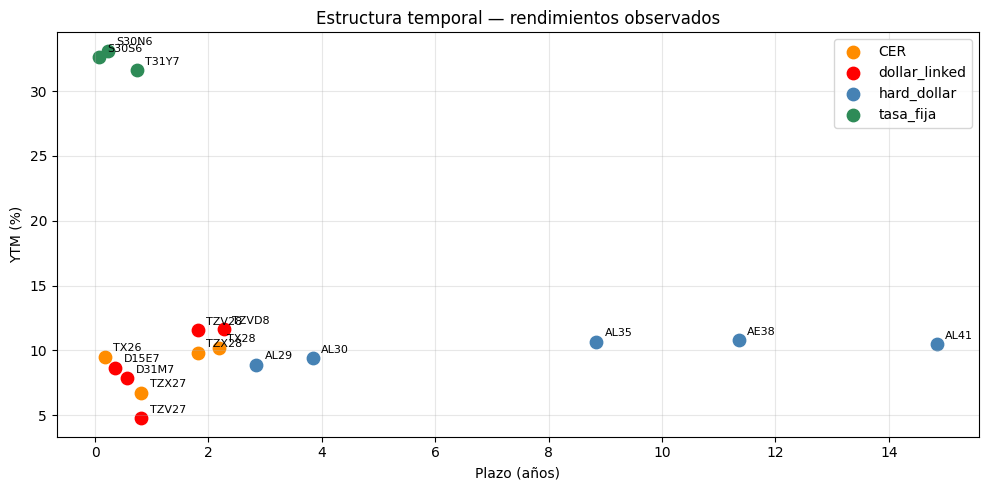

In [83]:
df_plot = bonos[bonos["ytm"].notna()].copy()

colores = {
    "hard_dollar": "steelblue",
    "dollar_linked": "red",
    "CER":         "darkorange",
    "tasa_fija":   "seagreen",
    
}

# 1. CURVA NO AJUSTADA
fig, ax = plt.subplots(figsize=(10, 5))

for tipo, grupo in df_plot.groupby("tipo"):
    ax.scatter(
        grupo["plazo_anos"], grupo["ytm"] * 100,
        label=tipo, color=colores[tipo], s=80
    )
    for _, row in grupo.iterrows():
        ax.annotate(
            row["ticker"],
            (row["plazo_anos"], row["ytm"] * 100),
            textcoords="offset points", xytext=(6, 4), fontsize=8
        )

ax.set_xlabel("Plazo (años)")
ax.set_ylabel("YTM (%)")
ax.set_title("Estructura temporal — rendimientos observados")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se observa el mismo plazo para los bonos ya dichos

In [84]:
df_ns = df_plot.copy()
# FUNCIONES NS
def nelson_siegel(tau, beta0, beta1, beta2, lam):
    tau    = np.maximum(tau, 1e-6)
    factor = (1 - np.exp(-tau / lam)) / (tau / lam)
    return beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam))

def nelson_siegel_lam_fijo(lam_fijo):
    def _ns(tau, beta0, beta1, beta2):
        tau    = np.maximum(tau, 1e-6)
        factor = (1 - np.exp(-tau / lam_fijo)) / (tau / lam_fijo)
        return beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam_fijo))
    return _ns

def nelson_siegel_lam_b2_fijos(lam_fijo): #b2 = 0
    def _ns(tau, beta0, beta1):
        tau    = np.maximum(tau, 1e-6)
        factor = (1 - np.exp(-tau / lam_fijo)) / (tau / lam_fijo)
        return beta0 + beta1 * factor
    return _ns

# CONFIGURACIÓN POR CURVA #maximo de params es cantidad de puntos menos 1
config = {
    "hard_dollar":   {"lam": 7.75, "n_params": 3},#lambda fijo (el acercamiento con lambda libre no funciona bien (se puede observar en el grafico posterior si se ajusta params a 4 y lam a 0.9)
    "dollar_linked": {"lam": 0.50, "n_params": 4},#lambda libre #para cualquier valor de lambda funciona
    "CER":           {"lam": 0.50, "n_params": 3},#lambda fijo
    "tasa_fija":     {"lam": 0.50, "n_params": 2},#lambda y B2 fijos
}

# AJUSTE
ns_params = {}

for tipo, cfg in config.items():
    grupo = df_ns[df_ns["tipo"] == tipo].sort_values("plazo_anos")
    x     = grupo["plazo_anos"].values
    y     = grupo["ytm"].values
    lam   = cfg["lam"]

    if len(x) == 0:
        print(f"{tipo}: sin datos")
        ns_params[tipo] = None
        continue

    try:
        if cfg["n_params"] == 4:
            # λ libre — 4 parámetros, requiere ≥5 puntos para grado de libertad
            params, _ = curve_fit(
                nelson_siegel, x, y,
                p0     = [y.mean(), y[0] - y[-1], 0.0, lam],
                bounds = ([-1, -2, -2, 0.1], [2, 2, 2, 15]),
                maxfev = 10000
            )

        elif cfg["n_params"] == 3:
            # λ fijo, β₀/β₁/β₂ libres
            betas, _ = curve_fit(
                nelson_siegel_lam_fijo(lam), x, y,
                p0     = [y.mean(), y[0] - y[-1], 0.0],
                bounds = ([-1, -2, -2], [2, 2, 2]),
                maxfev = 10000
            )
            params = (*betas, lam)

        else:
            # λ y β₂ fijos — solo β₀/β₁ libres
            betas, _ = curve_fit(
                nelson_siegel_lam_b2_fijos(lam), x, y,
                p0     = [y.mean(), y[0] - y[-1]],
                bounds = ([-1, -2], [2, 2]),
                maxfev = 10000
            )
            params = (betas[0], betas[1], 0.0, lam)

        ns_params[tipo] = params
        print(f"{tipo:15s}  β₀={params[0]:.4f}  β₁={params[1]:.4f}"
              f"  β₂={params[2]:.4f}  λ={params[3]:.4f}")

    except RuntimeError as e:
        print(f"{tipo}: no convergió — {e}")
        ns_params[tipo] = None

# VERIFICACIÓN ECONÓMICA 
print("\n── Verificación de parámetros ──")
for tipo, params in ns_params.items():
    if params is None:
        continue
    beta0, beta1, beta2, lam = params
    tasa_largo = beta0
    tasa_corto = beta0 + beta1
    ok_largo   = "OK" if tasa_largo > 0 else "NOT OK β₀ negativo"
    ok_corto   = "OK" if tasa_corto > 0 else "NOT OK β₀+β₁ negativo (tasa corta irreal)"
    print(f"{tipo:15s}  largo={tasa_largo*100:.2f}%  {ok_largo}"
          f"  |  corto={tasa_corto*100:.2f}%  {ok_corto}")

hard_dollar      β₀=0.0232  β₁=0.0419  β₂=0.2121  λ=7.7500
dollar_linked    β₀=0.2103  β₁=0.0311  β₂=-0.5504  λ=0.3907
CER              β₀=0.1751  β₁=-0.0491  β₂=-0.2775  λ=0.5000
tasa_fija        β₀=0.3024  β₁=0.0292  β₂=0.0000  λ=0.5000

── Verificación de parámetros ──
hard_dollar      largo=2.32%  OK  |  corto=6.51%  OK
dollar_linked    largo=21.03%  OK  |  corto=24.14%  OK
CER              largo=17.51%  OK  |  corto=12.60%  OK
tasa_fija        largo=30.24%  OK  |  corto=33.16%  OK


In [85]:
grupo = df_ns[df_ns["tipo"] == "hard_dollar"].sort_values("plazo_anos")
# hard_dollar dollar_linked CER
#generar lambdas (no es totalmente confiable, pero sirve para tener un rango de búsqueda)
x = grupo["plazo_anos"].values
y = grupo["ytm"].values

resultados_lam = []

for lam_test in np.arange(0.5, 8.0, 0.25): #(comienzo, final, paso)
    try:
        betas, _ = curve_fit(
            nelson_siegel_lam_fijo(lam_test), x, y,
            p0=[y.mean(), y[0]-y[-1], 0.0],
            bounds=([-1,-2,-2],[2,2,2]),
            maxfev=5000
        )
        y_hat = nelson_siegel_lam_fijo(lam_test)(x, *betas)
        sse   = np.sum((y - y_hat)**2)
        beta0 = betas[0]
        resultados_lam.append({
            "lambda": lam_test,
            "SSE":    round(sse, 8),
            "beta0":  round(beta0, 4),
            "valido": beta0 > 0
        })
    except RuntimeError:
        continue

df_lam = pd.DataFrame(resultados_lam)
print(df_lam.to_string(index=False))
print(f"\nλ óptimo (menor SSE con β₀>0): "
      f"{df_lam[df_lam['valido']].sort_values('SSE').iloc[0]['lambda']}")

 lambda          SSE  beta0  valido
   0.50 1.544000e-05 0.1122    True
   0.75 1.533000e-05 0.1119    True
   1.00 1.477000e-05 0.1113    True
   1.25 1.363000e-05 0.1103    True
   1.50 1.207000e-05 0.1090    True
   1.75 1.035000e-05 0.1075    True
   2.00 8.710000e-06 0.1058    True
   2.25 7.260000e-06 0.1040    True
   2.50 6.040000e-06 0.1020    True
   2.75 5.020000e-06 0.1000    True
   3.00 4.190000e-06 0.0978    True
   3.25 3.510000e-06 0.0954    True
   3.50 2.960000e-06 0.0930    True
   3.75 2.500000e-06 0.0903    True
   4.00 2.120000e-06 0.0875    True
   4.25 1.810000e-06 0.0845    True
   4.50 1.550000e-06 0.0814    True
   4.75 1.330000e-06 0.0780    True
   5.00 1.140000e-06 0.0745    True
   5.25 9.900000e-07 0.0708    True
   5.50 8.500000e-07 0.0669    True
   5.75 7.400000e-07 0.0628    True
   6.00 6.400000e-07 0.0585    True
   6.25 5.600000e-07 0.0541    True
   6.50 4.800000e-07 0.0494    True
   6.75 4.200000e-07 0.0445    True
   7.00 3.700000e-07 0.0395 

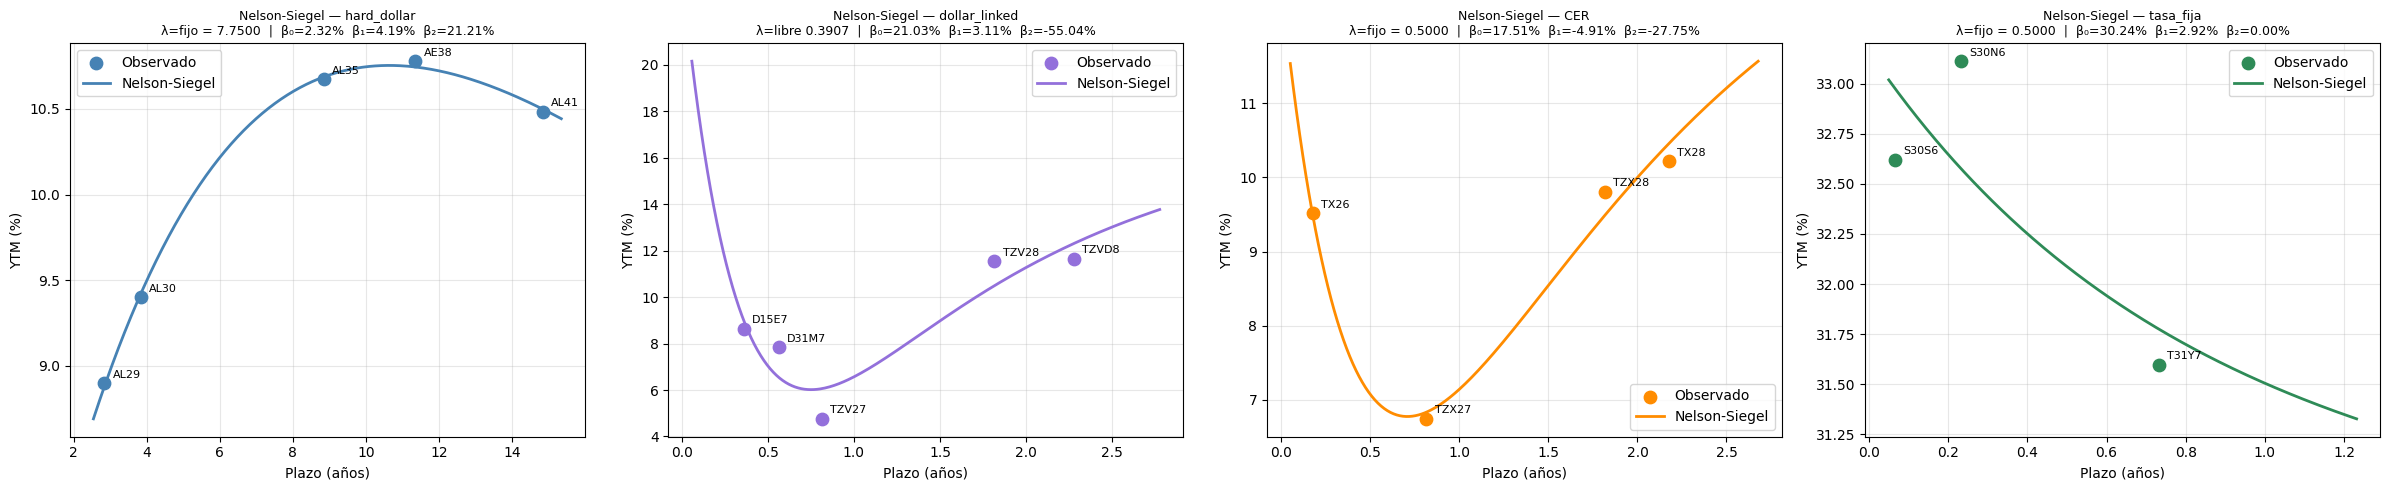

In [86]:
colores = {
    "hard_dollar":   "steelblue",
    "dollar_linked": "mediumpurple",
    "CER":           "darkorange",
    "tasa_fija":     "seagreen",
}

fig, axes = plt.subplots(1, len(ns_params), figsize=(6 * len(ns_params), 5))
if len(ns_params) == 1:
    axes = [axes]

for ax, (tipo, params) in zip(axes, ns_params.items()):
    # df_ns contiene los puntos realmente usados en el ajuste (con promedios)
    grupo = df_ns[df_ns["tipo"] == tipo].sort_values("plazo_anos")
    color = colores[tipo]

    # Puntos observados
    ax.scatter(
        grupo["plazo_anos"], grupo["ytm"] * 100,
        color=color, s=80, zorder=5, label="Observado"
    )
    for _, row in grupo.iterrows():
        ax.annotate(
            row["ticker"],
            (row["plazo_anos"], row["ytm"] * 100),
            textcoords="offset points", xytext=(6, 4), fontsize=8
        )

    # Curva ajustada
    if params is not None:
        x_min   = max(0.05, grupo["plazo_anos"].min() - 0.3)
        x_max   = grupo["plazo_anos"].max() + 0.5
        tau_rng = np.linspace(x_min, x_max, 300)
        y_fit   = nelson_siegel(tau_rng, *params) * 100
        ax.plot(tau_rng, y_fit, color=color, linewidth=2, label="Nelson-Siegel")

    # Título: indica si λ fue libre o fijo
    lam_val  = params[3] if params is not None else config[tipo]["lam"]
    n_params_tipo = config[tipo]["n_params"]
    lam_libre = (n_params_tipo == 4)
    titulo = (f"Nelson-Siegel — {tipo}\n"
              f"λ={'libre ' if lam_libre else 'fijo = '}{lam_val:.4f}  |  "
              f"β₀={params[0]*100:.2f}%  β₁={params[1]*100:.2f}%  β₂={params[2]*100:.2f}%")

    ax.set_xlabel("Plazo (años)")
    ax.set_ylabel("YTM (%)")
    ax.set_title(titulo, fontsize=9)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TZV27 y TZX27 (plazo ~0.8 años) tiran la curva a una forma de U, puede ser consistente con los mercados argentinos (estructura no estándar), y especialmente con las elecciones proximas a ocurrir en ~1 año (hoy 28/8)

S30S6 a muy corto plazo desde la fecha del analisis, el rendimiento ya no refleja expectativas de tasa sino pura liquidez de mercado secundario (rendimiento menor porque el riesgo de reinversión es casi nulo). NS no puede capturar este efecto de segmentación del tramo ultracorto con solo 3 puntos y β₂=0.

hard_dollar con lambda libre da un lambda menor al plazo observado y dispara los valores de los beta, lo cual anula interpretacion economica posible.

# FASE 4 TASAS

In [87]:
# FUNCIONES DE TASAS DERIVADAS

def tasa_spot(tau, params):
    """NS evaluado en τ"""
    return nelson_siegel(tau, *params)


def tasa_forward_instantanea(tau, params):
    """Derivada analítica de [τ·y(τ)] respecto a τ.
    f(τ) = β₀ + β₁·exp(-τ/λ) + β₂·(τ/λ)·exp(-τ/λ)"""
    beta0, beta1, beta2, lam = params
    tau = np.maximum(tau, 1e-6)
    exp_t = np.exp(-tau / lam)
    return beta0 + beta1 * exp_t + beta2 * (tau / lam) * exp_t


def tasa_forward_discreta(tau1, tau2, params):
    """Tasa forward entre dos plazos discretos τ₁ y τ₂.
    f(τ₁,τ₂) = [(1+y(τ₂))^τ₂ / (1+y(τ₁))^τ₁]^(1/(τ₂-τ₁)) - 1"""
    y1 = tasa_spot(tau1, params)
    y2 = tasa_spot(tau2, params)
    return ((1 + y2)**tau2 / (1 + y1)**tau1) ** (1 / (tau2 - tau1)) - 1


def tasa_par(T, params, frecuencia=2):
    if frecuencia == 0:
        return tasa_spot(T, params)
    periodo = 1 / frecuencia
    cupones = np.arange(periodo, T + 1e-9, periodo)
    if len(cupones) == 0:          # T < un período → par = spot
        return tasa_spot(T, params)
    descuentos = np.array([1 / (1 + tasa_spot(t, params))**t for t in cupones])
    return frecuencia * (1 - descuentos[-1]) / descuentos.sum()

In [88]:
rangos_tau = {
    "hard_dollar":   np.linspace(2.5,  15.5, 300),
    "dollar_linked": np.linspace(0.1,   2.8, 300),
    "CER":           np.linspace(0.1,   2.5, 300),
    "tasa_fija":     np.linspace(0.05,  1.0, 300),
}

plazos_tabla = {
    "hard_dollar":   [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "dollar_linked": [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5],
    "CER":           [0.5, 0.75, 1.0, 1.5, 2.0],   # arranca en 0.5
    "tasa_fija":     [1/12, 2/12, 3/12, 4/12, 5/12, 6/12, 9/12],
}

# Frecuencia de cupón para tasa_par por curva
# dollar_linked y tasa_fija son cero cupón, par = spot (se reporta igual)
frecuencia_par = {
    "hard_dollar":   2,
    "dollar_linked": 0,
    "CER":           2,
    "tasa_fija":     0,
}

# Intervalo de forward discreto por curva
intervalo_fwd = {
    "hard_dollar":   0.5,     # cupon semestral
    "dollar_linked": 0.25,    # trimestral, curva corta
    "CER":           0.5,     # cupon semestral
    "tasa_fija":     1/12,    # mensual, vencimientos < 1 año
}

tablas = {}

for tipo, params in ns_params.items():
    if params is None:
        continue

    plazos = plazos_tabla[tipo]
    frec   = frecuencia_par[tipo]
    delta  = intervalo_fwd[tipo]
    filas  = []

    for T in plazos:
        spot    = tasa_spot(T, params)
        fwd_ins = tasa_forward_instantanea(T, params)

        # Forward discreta: solo si hay margen de plazo suficiente
        if T >= delta:
            fwd_disc = tasa_forward_discreta(T, T + delta, params)
        else:
            fwd_disc = np.nan

        # Tasa par: para cero cupón coincide con spot
        if frec == 0:
            par = spot
        else:
            par = tasa_par(T, params, frecuencia=frec)

        filas.append({
            "plazo_anos":    round(T, 4),
            "spot_%":        round(spot     * 100, 4),
            "forward_ins_%": round(fwd_ins  * 100, 4),
            f"forward_{int(delta*12)}m_%": round(fwd_disc * 100, 4)
                                           if not np.isnan(fwd_disc) else np.nan,
            "par_%":         round(par      * 100, 4),
        })

    tablas[tipo] = pd.DataFrame(filas)
    print(f"\n── {tipo} ──")
    print(tablas[tipo].to_string(index=False))


── hard_dollar ──
 plazo_anos  spot_%  forward_ins_%  forward_6m_%   par_%
          3  8.9741        10.7350       10.9291  8.6972
          4  9.4974        11.3491       11.4707  9.1462
          5  9.9060        11.6912       11.7529  9.4840
          6 10.2167        11.8180       11.8310  9.7330
          7 10.4443        11.7767       11.7508  9.9113
          8 10.6014        11.6062       11.5501 10.0340
          9 10.6989        11.3383       11.2600 10.1130
         10 10.7464        10.9992       10.9055 10.1582
         11 10.7520        10.6099       10.5068 10.1770
         12 10.7227        10.1876       10.0802 10.1757
         13 10.6647         9.7460        9.6385 10.1590
         14 10.5830         9.2960        9.1918 10.1306
         15 10.4822         8.8460        8.7478 10.0935

── dollar_linked ──
 plazo_anos  spot_%  forward_ins_%  forward_3m_%   par_%
       0.25 11.6979         4.0979        2.5843 11.6979
       0.50  7.0442         2.3062        3.9948

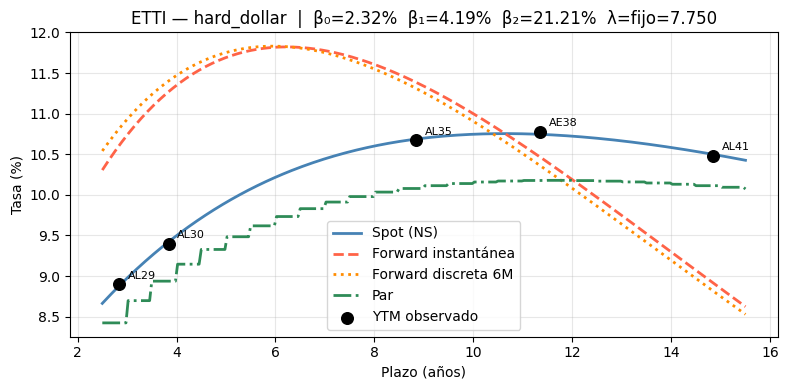

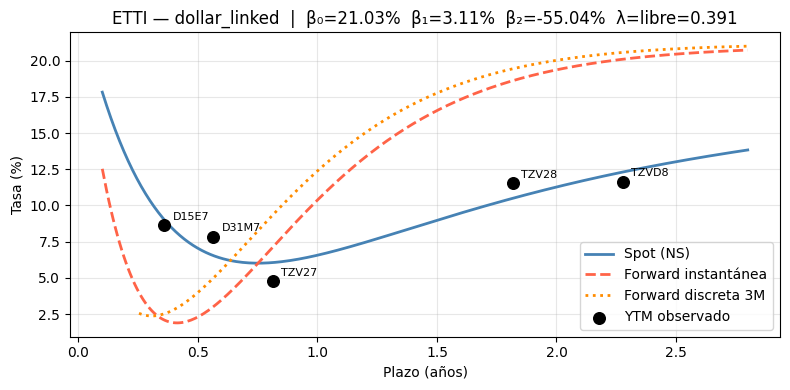

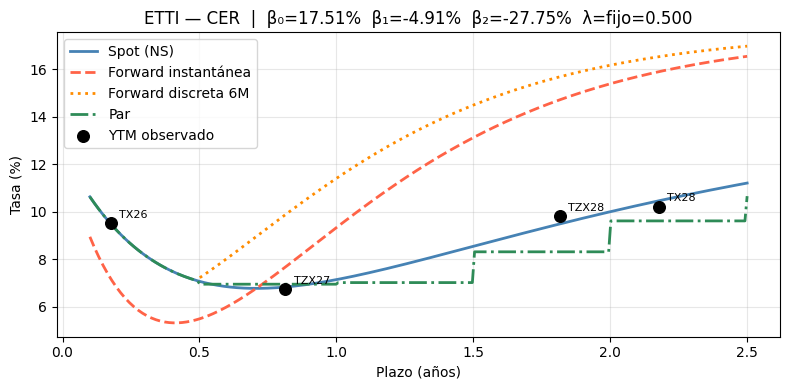

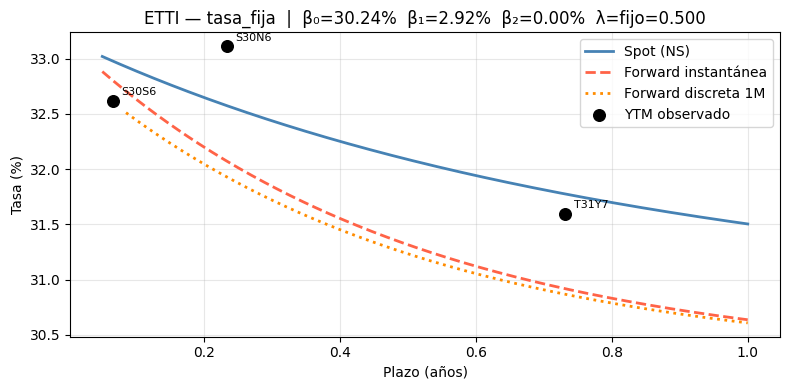

In [89]:
colores_tasa = {
    "spot":        "steelblue",
    "forward_ins": "tomato",
    "forward_disc": "darkorange",
    "par":         "seagreen",
}

for tipo, params in ns_params.items():
    if params is None:
        continue

    tau     = rangos_tau[tipo]
    delta   = intervalo_fwd[tipo]
    frec    = frecuencia_par[tipo]
    spot    = tasa_spot(tau, params) * 100
    fwd_ins = tasa_forward_instantanea(tau, params) * 100
    par_vals = np.array([tasa_par(t, params, frecuencia=frec) * 100 for t in tau])

    # Forward discreta con intervalo específico por curva
    tau_fwd  = tau[tau >= delta]
    fwd_disc = np.array([
        tasa_forward_discreta(t, t + delta, params) * 100
        for t in tau_fwd
    ])

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(tau,     spot,     color=colores_tasa["spot"],
            linewidth=2, label="Spot (NS)")
    ax.plot(tau,     fwd_ins,  color=colores_tasa["forward_ins"],
            linewidth=2, linestyle="--", label="Forward instantánea")
    ax.plot(tau_fwd, fwd_disc, color=colores_tasa["forward_disc"],
            linewidth=2, linestyle=":",
            label=f"Forward discreta {int(delta*12)}M")
    # Par solo si tiene sentido (instrumentos con cupón)
    if frec > 0:
        ax.plot(tau, par_vals, color=colores_tasa["par"],
                linewidth=2, linestyle="-.", label="Par")

    # Puntos observados — usar df_ns para consistencia con el ajuste
    obs = df_ns[df_ns["tipo"] == tipo].sort_values("plazo_anos")
    ax.scatter(
        obs["plazo_anos"], obs["ytm"] * 100,
        color="black", zorder=6, s=70, label="YTM observado"
    )
    for _, row in obs.iterrows():
        ax.annotate(
            row["ticker"],
            (row["plazo_anos"], row["ytm"] * 100),
            textcoords="offset points", xytext=(6, 4), fontsize=8
        )

    lam_libre = config[tipo]["n_params"] == 4
    ax.set_xlabel("Plazo (años)")
    ax.set_ylabel("Tasa (%)")
    ax.set_title(
        f"ETTI — {tipo}  |  "
        f"β₀={params[0]*100:.2f}%  β₁={params[1]*100:.2f}%  "
        f"β₂={params[2]*100:.2f}%  "
        f"λ={'libre=' if lam_libre else 'fijo='}{params[3]:.3f}"
    )
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# FASE 5 DURATION Y CONVEXITY

In [90]:
def get_params(tipo):
    return ns_params.get(tipo)

In [91]:
# Precio teórico con curva spot 
def precio_teorico(flujos, params):
    """Descuenta cada flujo con la tasa spot NS correspondiente a su plazo.
    flujos: lista de (plazo_años, monto)"""
    return sum(cf / (1 + tasa_spot(t, params))**t for t, cf in flujos)

In [92]:
# Duración de Macaulay
def duracion_macaulay(flujos, params, precio):
    """Promedio ponderado de plazos, donde el peso de cada flujo es su valor presente relativo al precio total."""
    return sum(
        t * (cf / (1 + tasa_spot(t, params))**t)
        for t, cf in flujos
    ) / precio


In [93]:
# Duración modificada
def duracion_modificada(dur_mac, ytm, frecuencia):
    """D_mod = D_mac / (1 + ytm/m)
    donde m = pagos por año.
    Para cero cupón: m=1 por convención."""
    m = frecuencia if frecuencia > 0 else 1
    return dur_mac / (1 + ytm / m)

In [94]:
# Convexidad 
def convexidad(flujos, params, precio, frecuencia):
    """C = Σ [t*(t + 1/m) * CF_t / (1+y_t)^t] / (P * (1 + y/m)^2)
    Aproximación estándar usando tasa spot por plazo."""
    m = frecuencia if frecuencia > 0 else 1
    numerador = sum(
        t * (t + 1/m) * cf / (1 + tasa_spot(t, params))**t
        for t, cf in flujos
    )
    return numerador / precio

In [95]:
# APLICACIÓN AL DATAFRAME

metricas = []

for _, row in bonos.iterrows():
    ticker  = row["ticker"]
    tipo    = row["tipo"]
    params  = get_params(tipo)
    precio  = row["precio_sucio"]
    ytm     = row["ytm"]
    frec    = int(row["frecuencia"])

    # Sin params NS o sin YTM: saltar
    if params is None or pd.isna(ytm):
        metricas.append({
            "ticker": ticker, "precio_teorico": np.nan,
            "dur_mac": np.nan, "dur_mod": np.nan, "convexidad": np.nan
        })
        continue

    # Generar flujos futuros
    if frec == 0:
        # Cero cupón: un único flujo al vencimiento
        vt_vto = row["vt_vencimiento"]
        if pd.isna(vt_vto):
            metricas.append({
                "ticker": ticker, "precio_teorico": np.nan,
                "dur_mac": np.nan, "dur_mod": np.nan, "convexidad": np.nan
            })
            continue
        flujos = [(row["plazo_anos"], vt_vto)]
    else:
        flujos = generar_flujos(
            ticker           = ticker,
            hoy              = hoy,
            ultimo_pago_dict = ultimo_pago,
            amort_schedules  = amort_schedules,
            vt_inicial       = row["valor_tecnico"],
            cupon            = row["cupon"],
            frecuencia       = frec,
            vencimiento      = row["vencimiento"],
            cupon_schedules  = cupon_schedules,
        )

    if not flujos:
        metricas.append({
            "ticker": ticker, "precio_teorico": np.nan,
            "dur_mac": np.nan, "dur_mod": np.nan, "convexidad": np.nan
        })
        continue

    # HARD DOLLAR
    tc = row["tipo_cambio"]
    if tipo == "hard_dollar":
        flujos_calc = [(t, cf * 100 * tc) for t, cf in flujos]
        precio_calc = precio
    else:
        flujos_calc = flujos
        precio_calc = precio

    p_teo  = precio_teorico(flujos_calc, params)
    d_mac  = duracion_macaulay(flujos_calc, params, p_teo)
    d_mod  = duracion_modificada(d_mac, ytm, frec)
    conv   = convexidad(flujos_calc, params, p_teo, frec)

    metricas.append({
        "ticker":        ticker,
        "precio_teorico": round(p_teo, 4),
        "dur_mac":        round(d_mac, 4),
        "dur_mod":        round(d_mod, 4),
        "convexidad":     round(conv, 4),
    })

df_metricas = pd.DataFrame(metricas)
bonos = bonos.merge(df_metricas, on="ticker", how="left")

print(bonos[["ticker", "tipo", "precio_sucio", "precio_teorico",
             "ytm", "dur_mac", "dur_mod", "convexidad"]].to_string(index=False))

ticker          tipo  precio_sucio  precio_teorico      ytm  dur_mac  dur_mod  convexidad
  AL30   hard_dollar      84860.00      85983.5823 0.093999   1.9635   1.8754      6.1246
  AL35   hard_dollar     115560.00     118485.8170 0.106728   5.4025   5.1289     36.6775
  AL29   hard_dollar      82580.00      83308.5293 0.088975   1.5208   1.4560      3.7979
  AL41   hard_dollar     108800.00     110361.6054 0.104833   5.7980   5.5093     50.6665
  AE38   hard_dollar     120750.00     124611.6213 0.107790   4.5639   4.3305     32.2117
 TZV27 dollar_linked     147800.00     146323.9622 0.047603   0.8137   0.7767      1.4758
 TZV28 dollar_linked     125880.00     128051.9804 0.115395   1.8164   1.6285      5.1159
 TZVD8 dollar_linked     119450.00     117854.5225 0.116457   2.2767   2.0392      7.4601
 D15E7 dollar_linked     149000.00     148813.1423 0.086437   0.3589   0.3303      0.4877
 D31M7 dollar_linked     147100.00     148107.6582 0.078379   0.5644   0.5234      0.8829
  TX26    

In [96]:
# Variación de precio ante shock de tasas
def delta_precio_D(precio, dur_mod, delta_y):
    """ΔP ≈ -D_mod * Δy * P
    Precio estimado post-shock."""
    return precio * (-dur_mod * delta_y)
def delta_precio_DC(precio, dur_mod, conv, delta_y):
    """ΔP ≈ -D_mod * Δy * P + 0.5 * C * Δy² * P
    Precio estimado post-shock."""
    return precio * (-dur_mod * delta_y + 0.5 * conv * delta_y**2)

precios = []

for _, row in bonos.iterrows():
    ticker  = row["ticker"]
    tipo    = row["tipo"]
    precio  = row["precio_sucio"]
    ytm     = row["ytm"]
    frec    = int(row["frecuencia"])
    
    diff_d = delta_precio_D(precio, row["dur_mod"], delta_y=0.01)
    precio_d = precio + delta_precio_D(precio, row["dur_mod"], delta_y=0.01)
    diff_dc = delta_precio_DC(precio, row["dur_mod"], row["convexidad"], delta_y=0.01)
    precio_dc = precio + delta_precio_DC(precio, row["dur_mod"], row["convexidad"], delta_y=0.01)
    
    precios.append({
            "ticker":        ticker,
            "precio original":   round(precio, 4),
            "diff dur.":         round(diff_d, 4),
            "precio dur.":       round(precio_d, 4),
            "diff dur.con.":     round(diff_dc, 4),
            "precio dur.con.":   round(precio_dc, 4),
        })

df_precios = pd.DataFrame(precios)
df_precios

,ticker,precio original,diff dur.,precio dur.,diff dur.con.,precio dur.con.
0,AL30,84860.00,-1591.4644,83268.5356,-1565.4778,83294.5222
1,AL35,115560.00,-5926.9568,109633.0432,-5715.0342,109844.9658
2,AL29,82580.00,-1202.3648,81377.6352,-1186.6833,81393.3167
3,AL41,108800.00,-5994.1184,102805.8816,-5718.4926,103081.5074
4,AE38,120750.00,-5229.0787,115520.9212,-5034.6006,115715.3994
5,TZV27,147800.00,-1147.9626,146652.0374,-1137.0564,146662.9436
6,TZV28,125880.00,-2049.9558,123830.0442,-2017.7563,123862.2437
7,TZVD8,119450.00,-2435.8244,117014.1756,-2391.2690,117058.7310
8,D15E7,149000.00,-492.1470,148507.8530,-488.5136,148511.4864
9,D31M7,147100.00,-769.9214,146330.0786,-763.4277,146336.5723


# DATOS PARA EXCEL Y DASHBOARD

In [97]:
# Exportar directo desde Python para tener datos actualizados
bonos[["ticker","tipo","precio_sucio", "precio_teorico","ytm","dur_mac","dur_mod","convexidad","plazo_anos"]]\
    .to_csv("bonos_metricas.csv", index=False)

In [98]:
#Curvas NS
df_curvas = pd.concat(tablas).reset_index(drop=False)
df_curvas.to_csv("curvas_NS.csv", index=False)


In [99]:
# Curva 300 puntos para PowerBI
curvas_300 = []

for tipo, params in ns_params.items():
    if params is None:
        continue
    tau  = rangos_tau[tipo]
    frec = frecuencia_par[tipo]
    for t in tau:
        curvas_300.append({
            "tipo":            tipo,
            "plazo_anos":      round(float(t), 4),
            "spot_%":          round(tasa_spot(t, params) * 100, 4),
            "forward_ins_%":   round(tasa_forward_instantanea(t, params) * 100, 4),
            "par_%":           round(tasa_par(t, params, frecuencia=frec) * 100, 4),
        })

df_curvas_300 = pd.DataFrame(curvas_300)
df_curvas_300.to_csv("curvas_NS_300.csv", index=False)